In [12]:
# Helper functions for Plotting

import math

import matplotlib.pyplot as plt

import matplotlib.colors as mpl_colors
from matplotlib.patches import Rectangle



In [27]:
def plot_colortable(colors, *, ncols=4, sort_colors=True):

    cell_width = 212
    cell_height = 22
    swatch_width = 48
    margin = 12

    # Sort colors by hue, saturation, value and name.
    if sort_colors is True:
        names = sorted(
            colors, key=lambda c: tuple(mpl_colors.rgb_to_hsv(mpl_colors.to_rgb(colors[c])))
        )
    else:
        names = list(colors)
    
    n = len(names)
    nrows = math.ceil(n / ncols)

    # Calculate the width and height of the figure.
    width = cell_width * ncols + 2 * margin
    height = cell_height * nrows + 2 * margin
    dpi = 72

    fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
    fig.subplots_adjust(margin / width, margin / height, (width - margin) /     width, (height - margin) / height)

    ax.set_xlim(0, cell_width * ncols)
    ax.set_ylim(cell_height * (nrows-0.5), -cell_height / 2.)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.set_axis_off()

    for i, name in enumerate(names):
        row = i % nrows
        col = i // nrows
        y = row * cell_height

        swatch_start_x = cell_width * col
        text_pos_x = cell_width * col + swatch_width + 7

        ax.text(text_pos_x, y, name, fontsize=14,
                horizontalalignment='left',
                verticalalignment='center')

        ax.add_patch(
            Rectangle(
                xy=(swatch_start_x, y - 9),
                width=swatch_width,
                height=18,
                facecolor=colors[name],
                edgecolor='0.7',
            )
        )
        
    plt.close(fig)
    return fig

    

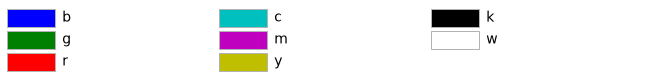

In [29]:
plot_colortable(mpl_colors.BASE_COLORS, ncols=3, sort_colors=False)

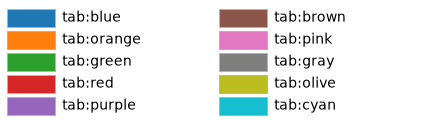

In [30]:
plot_colortable(mpl_colors.TABLEAU_COLORS, ncols=2, sort_colors=False)